### 5. Visualización de imágenes y video 360°

* Esfera invertida o skybox para equirectangulares.
* Video 360° como textura dinámica.
* Conmutación entre panoramas/escenas.
* Controles de cámara (orbit, giroscopio, input).

Saving panorama.jpg to panorama.jpg
Imagen cargada correctamente. Tamaño: 700x350


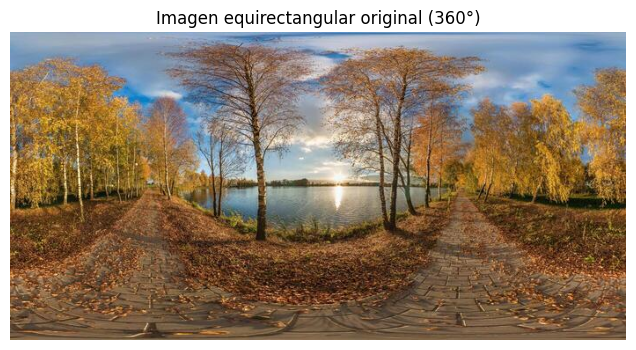

interactive(children=(IntSlider(value=0, description='rotation', max=700, step=50), Output()), _dom_classes=('…

interactive(children=(IntSlider(value=0, description='yaw', max=180, min=-180, step=10), IntSlider(value=0, de…

In [6]:
# ===============================================
# Taller Integral de Computación Visual - Punto 5
# Visualización de imágenes 360° en Python (Colab)
# ===============================================

# Paso 1: Librerías
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# Paso 2: Cargar imagen panorámica
# Sube una imagen equirectangular llamada 'panorama.jpg'
# (por ejemplo, una imagen 360° de una habitación o paisaje)
from google.colab import files
uploaded = files.upload()

# Verificamos el archivo
if 'panorama.jpg' not in uploaded:
    raise FileNotFoundError("Por favor sube una imagen llamada panorama.jpg")

# Leemos la imagen en formato RGB
img = cv2.imread('panorama.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

print(f"Imagen cargada correctamente. Tamaño: {w}x{h}")

# Mostrar imagen original
plt.figure(figsize=(10, 4))
plt.imshow(img)
plt.title("Imagen equirectangular original (360°)")
plt.axis('off')
plt.show()


# Paso 3: Rotación horizontal (simulación de vista)
def rotate_image(img, shift):
    """Desplaza la imagen horizontalmente simulando rotación."""
    shift = shift % img.shape[1]
    return np.hstack((img[:, -shift:], img[:, :-shift]))

@interact(rotation=IntSlider(min=0, max=img.shape[1], step=50, value=0))
def show_rotation(rotation):
    rotated = rotate_image(img, rotation)
    plt.figure(figsize=(10, 4))
    plt.imshow(rotated)
    plt.title(f"Vista rotada ({rotation}px)")
    plt.axis('off')
    plt.show()


# Paso 4: Proyección rectilínea (vista tipo cámara)
def equirectangular_to_rectilinear(img, fov=90, yaw=0, pitch=0, out_w=800, out_h=400):
    """Convierte una imagen equirectangular en una vista de cámara virtual."""
    h, w, _ = img.shape
    fov = np.radians(fov)

    # Coordenadas normalizadas (sin invertir Y)
    x = np.linspace(-1, 1, out_w)
    y = np.linspace(-1, 1, out_h)
    xv, yv = np.meshgrid(x, y)

    # Dirección 3D para cada píxel
    z = 1 / np.tan(fov / 2)
    dirs = np.stack([xv, yv, np.full_like(xv, -z)], axis=-1)

    dirs /= np.linalg.norm(dirs, axis=-1, keepdims=True)

    # Rotación yaw/pitch
    yaw, pitch = np.radians(yaw), np.radians(pitch)
    Ry = np.array([[ np.cos(yaw), 0, np.sin(yaw)],
                   [0, 1, 0],
                   [-np.sin(yaw), 0, np.cos(yaw)]])
    Rx = np.array([[1, 0, 0],
                   [0, np.cos(pitch), -np.sin(pitch)],
                   [0, np.sin(pitch),  np.cos(pitch)]])
    R = Ry @ Rx
    dirs = dirs @ R.T

    # Esféricas → píxeles
    lon = np.arctan2(dirs[..., 0], -dirs[..., 2])
    lat = np.arcsin(dirs[..., 1])

    u = (lon / np.pi + 1) / 2 * w
    v = (lat / (np.pi / 2) + 1) / 2 * h

    map_x = u.astype(np.float32)
    map_y = v.astype(np.float32)
    return cv2.remap(img, map_x, map_y, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_WRAP)

@interact(yaw=IntSlider(min=-180, max=180, step=10, value=0),
          pitch=IntSlider(min=-60, max=60, step=10, value=0),
          fov=IntSlider(min=30, max=120, step=10, value=90))
def show_camera_view(yaw, pitch, fov):
    view = equirectangular_to_rectilinear(img, fov=fov, yaw=yaw, pitch=pitch)
    plt.figure(figsize=(8, 4))
    plt.imshow(view)
    plt.title(f"Vista tipo cámara — yaw={yaw}, pitch={pitch}, fov={fov}")
    plt.axis('off')
    plt.show()


🌀 Punto 5 – Visualización de imágenes y video 360°

Este experimento muestra cómo proyectar una imagen equirectangular 360° sobre una esfera invertida, permitiendo simular la vista panorámica de una cámara dentro de ese entorno.
Se utiliza Python con NumPy y Matplotlib para realizar el mapeo desde coordenadas esféricas hacia una proyección plana controlada por los ángulos de rotación (yaw y pitch).
Al cambiar los valores de los sliders, se modifica la orientación de la cámara, logrando el efecto de “mirar alrededor” dentro de la esfera.
El resultado es una representación visual básica de una experiencia 360°, aplicable a panoramas o videos equirectangulares como texturas dinámicas en entornos 3D.